In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the location dataset

data_path = "../data/interim/location_data.csv"

df_reader = pd.read_csv(data_path, chunksize=100000)

df_reader

# Data Loading and Sampling Process

## Loading the Dataset in Chunks

- The location dataset is loaded using `pandas.read_csv()` with the `chunksize` parameter.

- Instead of loading the entire dataset into memory at once, the dataset is processed in chunks of `100000` rows.

- This approach is memory efficient and useful for handling large-scale datasets.

```python
df_reader = pd.read_csv(data_path, chunksize=100000)
```

- The returned object is a `TextFileReader`, which acts as an iterator over the dataset chunks.


In [3]:
# do sampling

all_samples = []

df_reader = pd.read_csv(data_path, chunksize=100000)

for df in df_reader:
    all_samples.append(df.sample(500))


sample_df = pd.concat(all_samples, axis=0)

## Random Sampling from Each Chunk

- An empty list called `all_samples` is created to store sampled records.

- The dataset is again iterated chunk by chunk.

- From each chunk, `500` random samples are selected using:

```python
df.sample(500)
```

- These sampled subsets are appended into the `all_samples` list.

- This approach helps:
  - reduce computational cost
  - maintain representative geographic coverage
  - avoid loading millions of rows into memory

```python
for df in df_reader:
    all_samples.append(df.sample(500))
```


In [4]:
# size of sample df

sample_df.shape

(166500, 2)

In [5]:
sample_df

,pickup_latitude,pickup_longitude
82398,40.757568,-74.000877
88364,40.737759,-73.987938
70373,40.744759,-73.997353
52621,40.730900,-74.001411
8546,40.791195,-73.968765
...,...,...
33223222,40.756542,-73.975235
33212321,40.740334,-74.008041
33221944,40.729397,-73.987122
33206463,40.719662,-73.992996


## Combining All Samples

- All sampled subsets are concatenated into a single dataframe using:

```python
pd.concat(all_samples, axis=0)
```

- The final sampled dataframe contains:

```text
166500 rows × 2 columns
```

- The two selected features are:
  - `pickup_latitude`
  - `pickup_longitude`

- These coordinates represent taxi pickup locations.


Text(0, 0.5, 'Longitude')

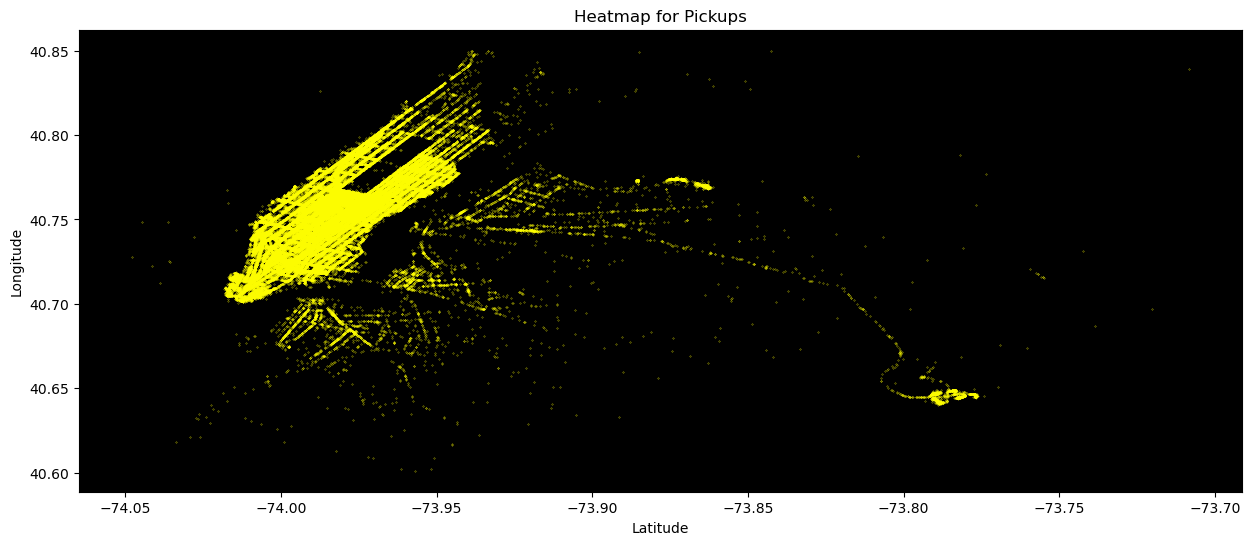

In [6]:
# plot the dataset on a scatterplot

fig,ax = plt.subplots(nrows=1,ncols=1,sharey=True,
                     figsize=(15,6))

ax.set_facecolor('k')
ax.scatter(sample_df['pickup_longitude'],sample_df['pickup_latitude'],s=0.05,color='yellow')
ax.set_title('Heatmap for Pickups')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')

# Initial Geospatial Visualization

## Scatterplot of Pickup Coordinates

- A scatterplot is created to visualize taxi pickup locations geographically.

- The plot uses:
  - black background
  - yellow points
  - extremely small marker size (`s=0.05`)

```python
ax.scatter(
    sample_df['pickup_longitude'],
    sample_df['pickup_latitude'],
    s=0.05,
    color='yellow'
)
```

- Longitude values are plotted on the x-axis.
- Latitude values are plotted on the y-axis.


## Observations from Initial Plot

- The pickup points form dense geographic clusters.

- Most pickup locations appear concentrated around urban regions of New York City.

- High-density regions likely correspond to:
  - business districts
  - commercial zones
  - tourist areas
  - transportation hubs

- Lower-density areas indicate:
  - suburban regions
  - low-demand zones
  - less populated areas

- The visualization resembles a geographic heatmap of taxi demand distribution.


In [7]:
from sklearn import set_config

set_config(transform_output='pandas')

In [8]:
# scale the input columns

from sklearn.preprocessing import StandardScaler

scale_samples = StandardScaler()

scaled_sample_df = scale_samples.fit_transform(sample_df)

# Feature Scaling Process

## Standardization of Coordinates

- The coordinate features are scaled using `StandardScaler`.

```python
from sklearn.preprocessing import StandardScaler
```

- Standardization transforms features so that:
  - mean becomes approximately `0`
  - standard deviation becomes approximately `1`

- This process is important for:
  - clustering algorithms
  - distance-based models
  - optimization algorithms
  - machine learning model stability

In [9]:
scaled_sample_df

,pickup_latitude,pickup_longitude
82398,0.240704,-0.727003
88364,-0.486420,-0.375173
70373,-0.229483,-0.631163
52621,-0.738176,-0.741524
8546,1.474981,0.146141
...,...,...
33223222,0.203039,-0.029774
33212321,-0.391907,-0.921796
33221944,-0.793344,-0.352976
33206463,-1.150675,-0.512711


## Applying Scaling

```python
scaled_sample_df = scale_samples.fit_transform(sample_df)
```

- Both latitude and longitude values are transformed into normalized z-score values.

- Example:
  - original coordinates around:
    - latitude ≈ `40`
    - longitude ≈ `-73`

- become scaled standardized values such as:
  - `-0.24`
  - `0.17`
  - `-1.39`


Text(0, 0.5, 'Longitude')

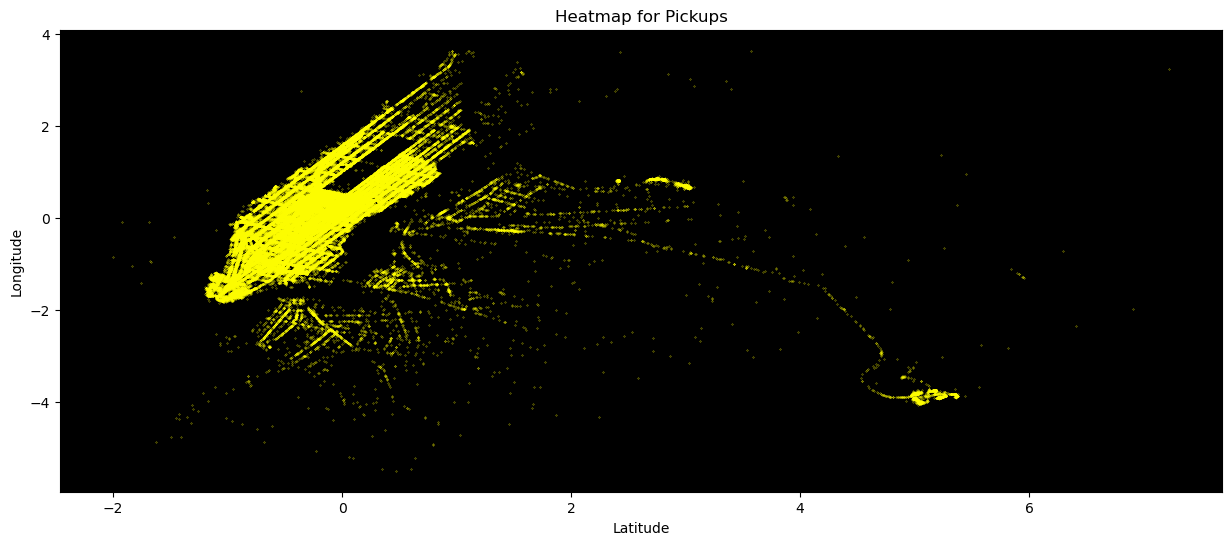

In [10]:
# plot the dataset on a scatterplot

fig,ax = plt.subplots(nrows=1,ncols=1,sharey=True,
                     figsize=(15,6))

ax.set_facecolor('k')
ax.scatter(scaled_sample_df['pickup_longitude'],scaled_sample_df['pickup_latitude'],s=0.05,color='yellow')
ax.set_title('Heatmap for Pickups')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')

# Visualization After Scaling

## Scatterplot of Scaled Coordinates

- Another scatterplot is generated using the scaled coordinate values.

- The overall geometric structure of the pickup distribution remains similar.

- However:
  - coordinate ranges become normalized
  - feature magnitudes become comparable
  - data becomes centered around zero


# Observations After Scaling

- Scaling does not change the spatial relationships between pickup points.

- The relative geographic structure remains preserved.

- Dense taxi demand regions remain clearly visible.

- Standardization improves:
  - numerical stability
  - clustering performance
  - convergence speed of machine learning algorithms

- Feature scaling is especially useful before applying:
  - K-Means clustering
  - DBSCAN
  - PCA
  - regression models
  - neural networks

In [11]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

In [12]:
df_reader = pd.read_csv(data_path, chunksize=100000)

In [13]:
# train the standard scaler

scaler = StandardScaler()

for chunk in df_reader:
    # fit the scaler
    scaler.partial_fit(chunk)

In [14]:
scaler

StandardScaler()

In [15]:
# get the scaler std and mean

print("The mean values are ", scaler.mean_)
print("The sigma values are ", scaler.scale_ )

The mean values are  [ 40.75107121 -73.9740618 ]
The sigma values are  [0.02722268 0.03675237]


# StandardScaler Training Process Using Incremental Learning

## Loading the Dataset in Chunks

- The dataset is loaded using:

```python
pd.read_csv(data_path, chunksize=100000)
```

- Instead of loading the entire dataset into memory at once, the data is processed incrementally in chunks of `100000` rows.

- This approach is memory efficient and suitable for large-scale datasets.

- The dataset contains:
  - pickup latitude
  - pickup longitude

which represent taxi pickup coordinates.

---

# Initializing the StandardScaler

```python
scaler = StandardScaler()
```

- A `StandardScaler` object is created from :contentReference[oaicite:0]{index=0}.

- The purpose of `StandardScaler` is to normalize features so that:
  - mean becomes approximately `0`
  - standard deviation becomes approximately `1`

- Feature scaling is important because many machine learning algorithms are sensitive to feature magnitude differences.

---

# Incremental Scaling Using `partial_fit()`

```python
for chunk in df_reader:
    scaler.partial_fit(chunk)
```

- The scaler is trained incrementally using `partial_fit()`.

- Instead of fitting on the entire dataset at once, the scaler learns statistical properties chunk by chunk.

- `partial_fit()` updates:
  - feature mean
  - feature variance
  - feature standard deviation

incrementally over multiple batches.

---

# Why `partial_fit()` is Important

- `partial_fit()` is highly useful for:
  - large datasets
  - streaming data
  - memory-efficient machine learning
  - distributed systems

- This approach avoids:
  - memory overflow
  - loading entire dataset into RAM

- Incremental learning is commonly used in:
  - big data systems
  - online machine learning
  - real-time prediction systems

---

# Learned Statistical Parameters

## Mean Values

```python
The mean values are  [ 40.75107121 -73.9740618 ]
```

### Interpretation

- Average pickup latitude is approximately:

```text
40.75
```

- Average pickup longitude is approximately:

```text
-73.97
```

- These values are geographically consistent with New York City coordinates.

---

# Standard Deviation Values

```python
The sigma values are  [0.02722268 0.03675237]
```

### Interpretation

- Latitude values vary by approximately:

```text
0.027
```

- Longitude values vary by approximately:

```text
0.036
```

- These values represent the spread of pickup coordinates around the mean.

---

# Observations

- The scaler successfully learned the global statistical distribution of the dataset incrementally.

- Pickup coordinates appear concentrated around New York City geographic boundaries.

- The relatively small standard deviation values indicate:
  - dense urban clustering
  - concentrated pickup regions
  - limited geographic spread

- Using chunk-based scaling improves:
  - scalability
  - memory efficiency
  - processing speed for large datasets

- Incremental standardization is especially useful before:
  - clustering algorithms
  - K-Means
  - MiniBatchKMeans
  - PCA
  - distance-based machine learning methods

---

# Business Insight

- Standardized geographic coordinates help machine learning models identify:
  - taxi demand hotspots
  - passenger density regions
  - mobility patterns
  - urban transportation clusters

- Efficient scaling pipelines are critical for:
  - large-scale taxi analytics
  - real-time demand forecasting
  - distributed machine learning systems
  - production ML workflows

- Incremental preprocessing enables scalable AI systems to process continuously growing transportation datasets efficiently.

In [16]:
def haversine_distance(lat1:float, lon1:float, lat2:float, lon2:float):
    """
    Calculate haversine distances between two points given their latitude and
    longitude coordinates
    """
    
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(
        dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    
    earth_radius = 3958.8
    distance = earth_radius * c
    return distance

# Purpose

- The `haversine_distance()` function calculates the geographical distance between two locations using:
  - latitude
  - longitude coordinates

- The distance is returned in miles.

---

# Coordinate Conversion

```python
lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
```

- Converts latitude and longitude values from degrees to radians.
- Trigonometric functions require radian values.

---

# Difference Calculation

```python
dlon = lon2 - lon1
dlat = lat2 - lat1
```

- Calculates:
  - longitude difference
  - latitude difference

between the two geographic points.

---

# Haversine Formula

```python
a = np.sin(
    dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
```

- Applies the Haversine formula to compute spherical distance on Earth.

---

# Angular Distance

```python
c = 2 * np.arcsin(np.sqrt(a))
```

- Computes angular distance between the two points.

---

# Distance Calculation

```python
earth_radius = 3958.8
distance = earth_radius * c
```

- Uses Earth's radius in miles.
- Converts angular distance into actual geographic distance.

---

# Return Statement

```python
return distance
```

- Returns the final distance between the two locations.

---

# Observations

- The Haversine formula provides accurate geographic distance calculations.
- It accounts for Earth’s curvature unlike Euclidean distance.
- Commonly used in:
  - GPS systems
  - taxi demand prediction
  - ride-sharing applications
  - route optimization
  - geospatial analytics

In [17]:
def select_optimum_k(k_values):
    for k in k_values:
        df_reader = pd.read_csv(data_path, chunksize=100000)
        mini_batch = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42)
        
        for chunk in df_reader:
            # scale the chunk
            scaled_chunk = scaler.transform(chunk)
            # train the model
            mini_batch.partial_fit(scaled_chunk)
            
        # centroid values
        centroids = scaler.inverse_transform(mini_batch.cluster_centers_)
        # calculate distances
        all_distances = []
        for i in centroids:
            distances = []
            for j in centroids:
                distance = haversine_distance(i[0], i[1], j[0], j[1])
                distances.append(distance)
            all_distances.append(distances)
        all_distances = np.array(all_distances)
        # sort array
        sorted_distances = np.sort(all_distances, axis=-1)
        # nearby regions
        region_count = 8
        # selected distances
        selected_distances = sorted_distances[:, 1:region_count+1]
        # average distances
        avg_distances = selected_distances.mean(axis=1)
        # count averages that fit criteria
        counter = ((avg_distances >= 1.0) & (avg_distances <= 1.5)).sum()
        percentage = ((avg_distances >= 1.0) & (avg_distances <= 1.5)).mean()
        print(f"For {k} clusters, the number of nearby regions that fits criteria are {counter} and is {percentage * 100:.1f}% regions of total")


# Process Flow

## Iterating Through Different Cluster Values

```python
for k in k_values:
```

- The function tests multiple values of `k`.
- Each `k` represents the number of clusters for `MiniBatchKMeans`.

---

# Loading Dataset in Chunks

```python
df_reader = pd.read_csv(data_path, chunksize=100000)
```

- The dataset is loaded incrementally in chunks.
- This improves memory efficiency for large datasets.

---

# Initializing MiniBatchKMeans

```python
mini_batch = MiniBatchKMeans(
    n_clusters=k,
    n_init=10,
    random_state=42
)
```

- Initializes the clustering model.
- `MiniBatchKMeans` is used because it is faster and scalable for large datasets.

Parameters:
- `n_clusters=k` → number of clusters
- `n_init=10` → model initialization attempts
- `random_state=42` → reproducibility

---

# Scaling and Incremental Training

```python
scaled_chunk = scaler.transform(chunk)
mini_batch.partial_fit(scaled_chunk)
```

- Each chunk is standardized using the trained scaler.
- `partial_fit()` trains the clustering model incrementally.

This approach:
- reduces memory usage
- supports large-scale training
- improves scalability

---

# Extracting Cluster Centroids

```python
centroids = scaler.inverse_transform(
    mini_batch.cluster_centers_
)
```

- Converts scaled centroid coordinates back to original geographic coordinates.

---

# Distance Calculation Between Clusters

```python
distance = haversine_distance(i[0], i[1], j[0], j[1])
```

- Calculates geographic distance between cluster centroids using the Haversine formula.

- Distances are measured in miles.

---

# Sorting Nearby Distances

```python
sorted_distances = np.sort(all_distances, axis=-1)
```

- Distances are sorted for each centroid.
- Helps identify nearest neighboring regions.

---

# Selecting Nearby Regions

```python
region_count = 8
selected_distances = sorted_distances[:, 1:region_count+1]
```

- Selects the nearest 8 neighboring clusters.
- The first distance is skipped because it represents distance to itself (`0` miles).

---

# Average Neighbor Distance

```python
avg_distances = selected_distances.mean(axis=1)
```

- Computes the average distance of nearby neighboring regions.

---

# Cluster Quality Criteria

```python
(avg_distances >= 1.0) & (avg_distances <= 1.5)
```

- Checks whether average neighboring cluster distance lies between:
  - 1 mile
  - 1.5 miles

- This helps determine whether clusters are geographically balanced.

---

# Final Evaluation

```python
counter = ...
percentage = ...
```

- Counts how many clusters satisfy the distance criteria.
- Computes the percentage of valid clusters.

---

# Observations

- `MiniBatchKMeans` enables scalable clustering on large taxi datasets.
- Chunk-based training improves memory efficiency.
- Geographic distance validation ensures clusters are spatially meaningful.
- Haversine distance provides accurate real-world geographic measurements.
- The optimal `k` is selected based on neighborhood distance consistency.

---

# Business Insight

- Clustering helps divide the city into taxi demand regions.
- These regions can be used for:
  - demand forecasting
  - driver allocation
  - surge pricing
  - hotspot analysis
  - region-wise demand prediction

- Proper cluster selection improves:
  - geographic segmentation
  - operational efficiency
  - ride allocation strategies
  - transportation optimization

In [18]:
possible_k_values = np.arange(10,100,10)

possible_k_values

array([10, 20, 30, 40, 50, 60, 70, 80, 90])

In [19]:
# select the optimum value of K

select_optimum_k(k_values=possible_k_values)

For 10 clusters, the number of nearby regions that fits criteria are 0 and is 0.0% regions of total
For 20 clusters, the number of nearby regions that fits criteria are 6 and is 30.0% regions of total
For 30 clusters, the number of nearby regions that fits criteria are 9 and is 30.0% regions of total
For 40 clusters, the number of nearby regions that fits criteria are 8 and is 20.0% regions of total
For 50 clusters, the number of nearby regions that fits criteria are 7 and is 14.0% regions of total
For 60 clusters, the number of nearby regions that fits criteria are 10 and is 16.7% regions of total
For 70 clusters, the number of nearby regions that fits criteria are 13 and is 18.6% regions of total
For 80 clusters, the number of nearby regions that fits criteria are 14 and is 17.5% regions of total
For 90 clusters, the number of nearby regions that fits criteria are 17 and is 18.9% regions of total


In [20]:
df_reader = pd.read_csv(data_path, chunksize=100000)
mini_batch = MiniBatchKMeans(n_clusters=30, n_init=10, random_state=42)

for chunk in df_reader:
    # scale the chunk
    scaled_chunk = scaler.transform(chunk)
    # train the model
    mini_batch.partial_fit(scaled_chunk)
    
# centroid values
centroids = mini_batch.cluster_centers_

centroids

array([[ 1.94149572,  0.6614905 ],
       [-0.13980742, -0.07596928],
       [-1.99721801,  1.44528196],
       [-3.83635934,  5.15118517],
       [-1.16343866, -0.81227839],
       [ 0.42137614, -0.13488625],
       [ 0.72209007,  2.8610836 ],
       [-0.52924948, -0.39015448],
       [ 1.07003845,  0.56520318],
       [-2.24451716, -0.3303071 ],
       [-1.00166487, -0.4036074 ],
       [ 1.16185672, -0.10175947],
       [-0.08902033, -0.55920139],
       [ 0.31820801,  1.59046972],
       [-0.04552948, -0.25372558],
       [ 0.20846098, -0.35389222],
       [-1.31780812,  0.52314378],
       [ 2.79102906,  0.81932304],
       [ 0.28712745,  0.12935608],
       [ 0.73099844, -0.27639436],
       [-1.53772972, -1.0082658 ],
       [ 0.67692302,  0.39844824],
       [-0.76412025, -0.74701446],
       [ 1.62394033,  0.1378545 ],
       [-3.07963657, -0.43385234],
       [ 0.3506753 , -0.54018812],
       [-0.57100818, -0.17842182],
       [-0.38830582, -0.76072368],
       [-2.66479788,

# Process

- The dataset is loaded in chunks of `100000` rows for memory-efficient processing.
- `MiniBatchKMeans` is initialized with `30` clusters.
- Each chunk is scaled using `StandardScaler`.
- The clustering model is trained incrementally using `partial_fit()`.
- Final cluster centroids are extracted using `cluster_centers_`.

---

# Observations

- `MiniBatchKMeans` is suitable for large-scale datasets because it supports incremental training.
- Scaling improves clustering performance by normalizing coordinate values.
- The centroids represent important taxi pickup regions across the city.
- These clusters can be used for demand forecasting and hotspot analysis.

In [21]:
centroids = scaler.inverse_transform(mini_batch.cluster_centers_)

centroids.shape

centroids

array([[ 40.80392392, -73.94975046],
       [ 40.74726528, -73.97685385],
       [ 40.69670159, -73.92094427],
       [ 40.64663525, -73.78474354],
       [ 40.7193993 , -74.00391496],
       [ 40.7625422 , -73.97901919],
       [ 40.77072843, -73.8689102 ],
       [ 40.73666362, -73.9884009 ],
       [ 40.78020052, -73.95328925],
       [ 40.68996945, -73.98620137],
       [ 40.72380321, -73.98889533],
       [ 40.78270006, -73.9778017 ],
       [ 40.74864784, -73.99461378],
       [ 40.75973368, -73.91560827],
       [ 40.74983178, -73.98338682],
       [ 40.75674608, -73.98706818],
       [ 40.71519695, -73.95483503],
       [ 40.82705049, -73.94394974],
       [ 40.75888759, -73.96930766],
       [ 40.77097094, -73.98421995],
       [ 40.70921009, -74.01111796],
       [ 40.76949887, -73.95941789],
       [ 40.73026981, -74.00151635],
       [ 40.79527921, -73.96899532],
       [ 40.66723527, -73.9900069 ],
       [ 40.76061753, -73.993915  ],
       [ 40.73552684, -73.98061923],
 

# Process

- `mini_batch.cluster_centers_` returns centroid values in scaled format.
- `scaler.inverse_transform()` converts the scaled centroids back to original latitude and longitude coordinates.
- `centroids.shape` displays:
  - number of clusters
  - number of features

- The resulting centroid values represent actual geographic pickup locations.

---

# Observations

- The centroids correspond to important taxi pickup regions across the city.
- Converting centroids back to original coordinates makes them geographically interpretable.
- These cluster centers can be used for:
  - hotspot analysis
  - region segmentation
  - demand forecasting
  - driver allocation
  - spatial analysis

# Cluster Centroid Transformation

```python
centroids = scaler.inverse_transform(mini_batch.cluster_centers_)

centroids.shape

centroids
```

---

# Process

- `mini_batch.cluster_centers_` returns centroid values in scaled format.
- `scaler.inverse_transform()` converts the scaled centroids back to original latitude and longitude coordinates.
- `centroids.shape` displays:
  - number of clusters
  - number of features

- The resulting centroid values represent actual geographic pickup locations.

---

# Observations

- The centroids correspond to important taxi pickup regions across the city.
- Converting centroids back to original coordinates makes them geographically interpretable.
- These cluster centers can be used for:
  - hotspot analysis
  - region segmentation
  - demand forecasting
  - driver allocation
  - spatial analysis

In [22]:
# calculate distances
all_distances = []
for i in centroids:
    distances = []
    for j in centroids:
        distance = haversine_distance(i[0], i[1], j[0], j[1])
        distances.append(distance)
    all_distances.append(distances)
all_distances = np.array(all_distances)

# Process

- An empty list `all_distances` is created to store distances between cluster centroids.

- The outer loop iterates through each centroid.

- The inner loop calculates the distance from one centroid to every other centroid.

- `haversine_distance()` is used to compute geographic distance between coordinates.

- The calculated distances are stored in a temporary `distances` list.

- Each centroid’s distance list is appended to `all_distances`.

- Finally, the list is converted into a NumPy array for easier numerical operations.

- It will be a 30 X 30 Matrix

---

# Observations

- The resulting matrix contains pairwise distances between all cluster regions.
- Distance values represent geographic separation between taxi demand regions.
- Smaller distances indicate nearby pickup regions.
- This distance matrix helps analyze:
  - neighboring regions
  - spatial relationships
  - cluster density
  - geographic segmentation

In [23]:
all_distances.shape

(30, 30)

In [24]:
# sort array
sorted_distances = np.sort(all_distances, axis=-1)

sorted_distances

array([[ 0.        ,  1.17046275,  1.62644497,  1.64956641,  2.07449605,
         2.43174071,  2.90442913,  3.2434477 ,  3.27565262,  3.53740885,
         3.78050229,  3.79970162,  3.96017252,  4.13108335,  4.16372256,
         4.48294461,  4.81099377,  4.99426451,  5.06830264,  5.16566196,
         5.765128  ,  5.90274144,  6.13628226,  6.49173393,  7.28986507,
         7.56031049,  8.10147619,  8.67613248,  9.67668877, 13.88381717],
       [ 0.        ,  0.38520824,  0.83466661,  0.84554574,  0.89491143,
         0.93453618,  0.9497229 ,  1.06161155,  1.28395435,  1.39786924,
         1.68267844,  1.73935963,  1.74527216,  1.78680442,  2.1291437 ,
         2.39049179,  2.44883646,  2.49771118,  2.58829318,  3.18314532,
         3.31936779,  3.34286722,  3.9889529 ,  4.16372256,  4.5581976 ,
         4.84586092,  5.57235103,  5.77518367,  5.87736576, 12.23197903],
       [ 0.        ,  2.18727182,  2.33312628,  3.45017867,  3.60190277,
         4.0214796 ,  4.11861947,  4.15208245,  4

In [25]:
# nearby regions
region_count = 8
# selected distances
selected_distances = sorted_distances[:, 1:region_count+1]
# average distances
avg_distances = selected_distances.mean(axis=1)

In [26]:
selected_distances

array([[ 1.17046275,  1.62644497,  1.64956641,  2.07449605,  2.43174071,
         2.90442913,  3.2434477 ,  3.27565262],
       [ 0.38520824,  0.83466661,  0.84554574,  0.89491143,  0.93453618,
         0.9497229 ,  1.06161155,  1.28395435],
       [ 2.18727182,  2.33312628,  3.45017867,  3.60190277,  4.0214796 ,
         4.11861947,  4.15208245,  4.36409798],
       [ 7.93169228,  9.36855262,  9.64097158, 10.09315318, 10.39482286,
        10.56112547, 10.85291444, 10.97425053],
       [ 0.76151738,  0.79871063,  0.84332096,  1.44318852,  1.46133899,
         1.65214612,  2.07874566,  2.23510174],
       [ 0.56752242,  0.58123428,  0.64283085,  0.79082054,  0.90747837,
         1.06161155,  1.13278419,  1.26008803],
       [ 2.55912324,  3.86816694,  4.46322742,  4.73679633,  4.81099377,
         5.31727743,  5.50409572,  5.52711246],
       [ 0.41490598,  0.76069091,  0.8165102 ,  0.88895546,  0.88962214,
         0.94694645,  0.9497229 ,  1.38933145],
       [ 0.80596199,  1.29403148

In [27]:
avg_distances

array([2.29703004, 0.89876963, 3.52859488, 9.97718537, 1.40925875,
       0.86804628, 4.59834916, 0.88208569, 1.59066958, 2.26646269,
       1.22665091, 1.39749766, 0.87992819, 2.71684773, 0.78007248,
       0.79721075, 2.27350129, 3.6456581 , 1.02570843, 1.1165675 ,
       1.93409239, 1.34924415, 1.09340781, 1.82286886, 3.30517047,
       0.98753376, 1.02024965, 1.07522903, 2.8928434 , 2.14386745])

# Nearby Region Distance Analysis

# Process

- `region_count = 8` specifies the number of nearby neighboring regions to analyze.

- `sorted_distances[:, 1:region_count+1]` selects the nearest 8 neighboring cluster distances.
- The first column is skipped because it represents the distance of a centroid from itself (`0` miles).

- It is taken as 8 because of the directions (NORTH, SOUTH, EAST WEST, NORTHWEST, NORTHEAST, SOUTHWEST AND SOUTHEAST)

- `mean(axis=1)` calculates the average distance of nearby neighboring regions for each centroid.

---

# Observations

- Average neighboring distances help measure how closely clustered the taxi regions are geographically.
- Smaller average distances indicate dense urban pickup regions.
- Larger average distances indicate more spread-out regions.
- This analysis helps evaluate cluster quality and spatial distribution consistency.

In [28]:
((avg_distances >= 1.0) & (avg_distances <= 1.5)).mean()

np.float64(0.3)

# Clustering

In [29]:
df_reader = pd.read_csv(data_path, chunksize=100000)

In [30]:
# train the model

mini_batch = MiniBatchKMeans(n_clusters=30, n_init=10, random_state=42)

for chunk in df_reader:
    # scale the chunk
    scaled_chunk = scaler.transform(chunk)
    # train the model
    mini_batch.partial_fit(scaled_chunk)

In [31]:
mini_batch

MiniBatchKMeans(n_clusters=30, n_init=10, random_state=42)

In [32]:
# centroids of the model

mini_batch.cluster_centers_

array([[ 1.94149572,  0.6614905 ],
       [-0.13980742, -0.07596928],
       [-1.99721801,  1.44528196],
       [-3.83635934,  5.15118517],
       [-1.16343866, -0.81227839],
       [ 0.42137614, -0.13488625],
       [ 0.72209007,  2.8610836 ],
       [-0.52924948, -0.39015448],
       [ 1.07003845,  0.56520318],
       [-2.24451716, -0.3303071 ],
       [-1.00166487, -0.4036074 ],
       [ 1.16185672, -0.10175947],
       [-0.08902033, -0.55920139],
       [ 0.31820801,  1.59046972],
       [-0.04552948, -0.25372558],
       [ 0.20846098, -0.35389222],
       [-1.31780812,  0.52314378],
       [ 2.79102906,  0.81932304],
       [ 0.28712745,  0.12935608],
       [ 0.73099844, -0.27639436],
       [-1.53772972, -1.0082658 ],
       [ 0.67692302,  0.39844824],
       [-0.76412025, -0.74701446],
       [ 1.62394033,  0.1378545 ],
       [-3.07963657, -0.43385234],
       [ 0.3506753 , -0.54018812],
       [-0.57100818, -0.17842182],
       [-0.38830582, -0.76072368],
       [-2.66479788,

In [33]:
scaler.inverse_transform(mini_batch.cluster_centers_)

array([[ 40.80392392, -73.94975046],
       [ 40.74726528, -73.97685385],
       [ 40.69670159, -73.92094427],
       [ 40.64663525, -73.78474354],
       [ 40.7193993 , -74.00391496],
       [ 40.7625422 , -73.97901919],
       [ 40.77072843, -73.8689102 ],
       [ 40.73666362, -73.9884009 ],
       [ 40.78020052, -73.95328925],
       [ 40.68996945, -73.98620137],
       [ 40.72380321, -73.98889533],
       [ 40.78270006, -73.9778017 ],
       [ 40.74864784, -73.99461378],
       [ 40.75973368, -73.91560827],
       [ 40.74983178, -73.98338682],
       [ 40.75674608, -73.98706818],
       [ 40.71519695, -73.95483503],
       [ 40.82705049, -73.94394974],
       [ 40.75888759, -73.96930766],
       [ 40.77097094, -73.98421995],
       [ 40.70921009, -74.01111796],
       [ 40.76949887, -73.95941789],
       [ 40.73026981, -74.00151635],
       [ 40.79527921, -73.96899532],
       [ 40.66723527, -73.9900069 ],
       [ 40.76061753, -73.993915  ],
       [ 40.73552684, -73.98061923],
 

In [34]:
# perform predictions and assign clusters

sample_predictions = mini_batch.predict(scaled_sample_df)

sample_predictions.shape

(166500,)

In [35]:
np.unique(sample_predictions)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], dtype=int32)

# Clustering Process

## Model Training

```python
mini_batch = MiniBatchKMeans(
    n_clusters=30,
    n_init=10,
    random_state=42
)
```

- `MiniBatchKMeans` is initialized with `30` clusters.
- The dataset is processed incrementally using chunks for memory-efficient training.

```python
scaled_chunk = scaler.transform(chunk)
mini_batch.partial_fit(scaled_chunk)
```

- Each chunk is standardized using `StandardScaler`.
- `partial_fit()` performs incremental clustering on large-scale data.

---

# Cluster Centroids

```python
mini_batch.cluster_centers_
```

- Returns centroid coordinates in scaled format.

```python
scaler.inverse_transform(mini_batch.cluster_centers_)
```

- Converts centroids back to original latitude and longitude values.
- These centroids represent major taxi pickup regions across the city.

---

# Cluster Prediction

```python
sample_predictions = mini_batch.predict(scaled_sample_df)
```

- Assigns every pickup location to its nearest cluster.

```python
np.unique(sample_predictions)
```

- Shows that all `30` clusters are actively being used.

---

# Observations

- `MiniBatchKMeans` efficiently handles large datasets using chunk-based training.
- Clusters represent important geographic taxi demand regions.
- Standardization improves clustering performance and stability.
- The predicted cluster labels enable:
  - hotspot analysis
  - region segmentation
  - demand forecasting
  - spatial demand mapping
```

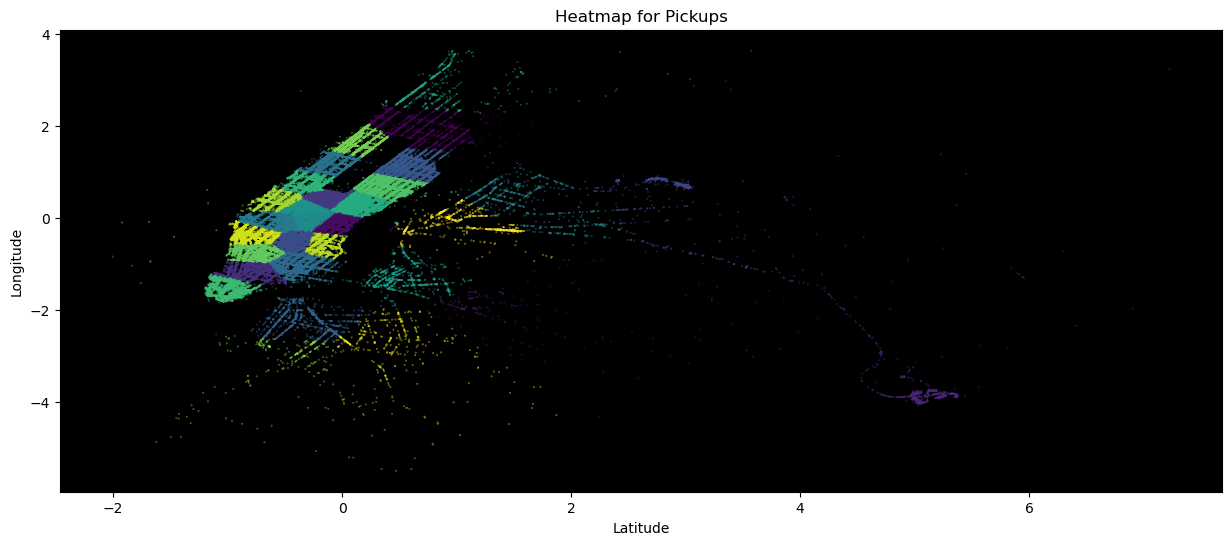

In [36]:
# plot the dataset on a scatterplot

fig,ax = plt.subplots(nrows=1,ncols=1,sharey=True,
                     figsize=(15,6))

ax.set_facecolor('k')
ax.scatter(scaled_sample_df['pickup_longitude'],scaled_sample_df['pickup_latitude'],
           s=0.05,c=sample_predictions)
ax.set_title('Heatmap for Pickups')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')

plt.show()

# Cluster Visualization

# Explanation

- A scatterplot is created to visualize clustered pickup locations.
- Pickup coordinates are plotted using:
  - longitude on x-axis
  - latitude on y-axis

- `c=sample_predictions` assigns different colors to different clusters.
- Each color represents a separate taxi demand region identified by `MiniBatchKMeans`.

---

# Observations

- Distinct geographic taxi demand regions are clearly visible.
- Dense urban pickup regions appear as tightly packed colored areas.
- Different colors represent different clusters only — the colors themselves do **not** indicate density level.
- Density is identified by:
  - how closely points are packed together
  - concentration of points in a region

- Highly dense pickup areas contain:
  - more overlapping points
  - compact spatial grouping

- Sparse regions contain:
  - fewer points
  - larger spacing between points

- The clustering successfully captures meaningful geographic demand patterns useful for:
  - hotspot detection
  - driver allocation
  - demand forecasting
  - surge pricing analysis